In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:

# 1. サンプルデータの作成（8人の健康診断結果）
# 身長(cm), 体重(kg), 腹囲(cm), 体脂肪率(%)という４次元のデータをベースにしています。
data = {
    'Name'   : ['User_A', 'User_B', 'User_C', 'User_D', 'User_E', 'User_F', 'User_G', 'User_H'],
    'Height' : [     180,      160,      170,      175,      155,      185,      165,      172],
    'Weight' : [      75,       50,       65,       90,       60,       80,       55,       85],
    'Waist'  : [      82,       68,       75,      105,       85,       88,       70,       98],
    'BodyFat': [      18,       22,       20,       32,       35,       15,       21,       30]
}

df = pd.DataFrame(data)
features = ['Height', 'Weight', 'Waist', 'BodyFat']
x = df.loc[:, features].values

# 2. 標準化（PCAの前処理）標準化しないとばらつきの軸がずれてしまう
x_scaled = StandardScaler().fit_transform(x)

# 3. PCAの実行（2次元に圧縮）引数で設定している
pca = PCA(n_components=2)
pc = pca.fit_transform(x_scaled)


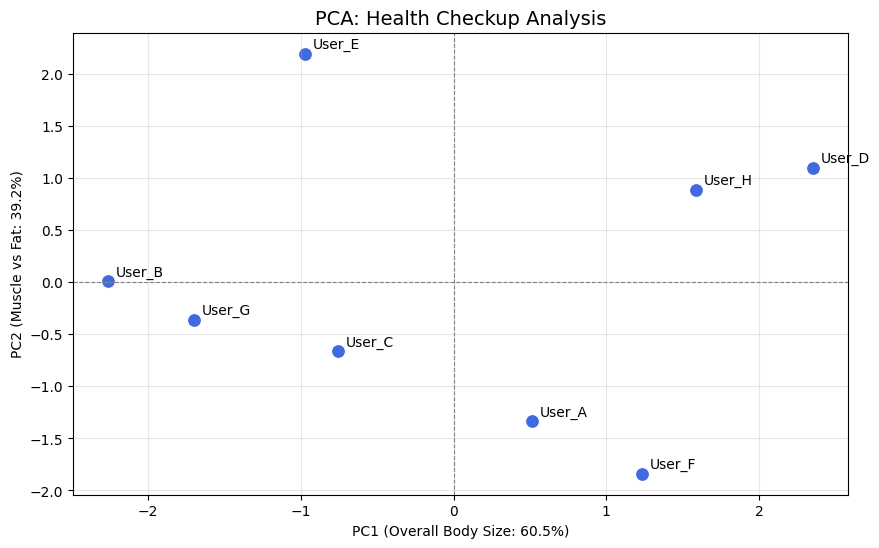

--- 各主成分に対する元の項目の影響度 ---
              PC1       PC2
Height   0.464244 -0.551391
Weight   0.641283 -0.018470
Waist    0.598443  0.286717
BodyFat  0.122880  0.783212


In [ ]:

# 結果のデータフレーム化
pca_df = pd.DataFrame(data=pc, columns=['PC1', 'PC2'])
pca_df['Name'] = df['Name']

# 4. 可視化
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, s=100, color='royalblue')

for i in range(pca_df.shape[0]):
    plt.text(pca_df.PC1[i]+0.05, pca_df.PC2[i]+0.05, pca_df.Name[i])

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('PCA: Health Checkup Analysis', fontsize=14)
plt.xlabel(f'PC1 (Overall Body Size: {pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 (Muscle vs Fat: {pca.explained_variance_ratio_[1]:.1%})')
plt.grid(True, alpha=0.3)
plt.show()

# 軸の意味を解釈するための「寄与」を表示
print("--- 各主成分に対する元の項目の影響度 ---")
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print(loadings)

横軸（第1主成分：PC1）：体の大きさ（ボリューム）  
縦軸（第2主成分：PC2）：体組成（スタイル・締まり具合）  

① 右上エリア（PC1：＋ / PC2：＋）【判定：大型・メタボ注意タイプ】  
② 右下エリア（PC1：＋ / PC2：－）【判定：大型・アスリートタイプ】  
③ 左下エリア（PC1：－ / PC2：－）【判定：小柄・スリムタイプ】  
④ 左上エリア（PC1：－ / PC2：＋）【判定：小柄・隠れ肥満タイプ】

🎯 まず結論：PCA が内部でやっていること  （超要点）  
標準化  
　→ 各特徴量を平均0・分散1にする

共分散行列を作る  
　→ 特徴量同士がどう一緒に変動するかを見る  
　　　・体重が増えると腹囲も増える  
　　　・体脂肪率が高い人は腹囲も大きい  
　　　・身長は体脂肪率とあまり関係ない  
　　こういう「一緒に増える／増えない」の関係を 数値で表した表が共分散行列です。
  


固有値・固有ベクトルを計算する  
　→ データのばらつきが最大になる方向（主成分）を見つける

その方向へ座標変換する  
　→ 元の4次元データを、2次元（PC1・PC2）に写す
  
  
**今回使用したデータは、体重・腹囲・体脂肪率は強く相関していて、身長はやや独立している。**

PCA はこれを見て：

　PC1：肥満度の軸（体重・腹囲・体脂肪率）

　PC2：身長の軸

のように自動で“軸”を作る。（分類ではなく、軸の再構成。）